# Predicting Wine Quality
In this notebook, we will be predicting the quality of wine based on the given dataset. You can find the competition and the dataset [here](https://www.kaggle.com/competitions/wine-quality-ordinal).

<div align="center">
<img src="https://www.kaggle.com/competitions/107916/images/header" />
</div>

## 1. Importing Libraries

In [166]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE

import warnings

### Configurations

In [2]:
warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style('darkgrid')

## 2. Loading Data

In [5]:
df = pd.read_csv('train.csv', index_col='id')

In [6]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
id,,,,,,,,,,,,
0,6.9,0.725,0.00,2.4,0.093,14.0,31.0,0.99640,3.48,0.54,9.8,5.0
1,7.2,0.610,0.06,1.6,0.084,6.0,14.0,0.99765,3.53,0.75,10.9,7.0
2,9.3,0.310,0.34,2.7,0.084,32.0,71.0,0.99760,3.25,0.87,9.3,7.0
3,6.4,0.440,0.09,2.5,0.082,4.0,12.0,0.99498,3.32,0.84,9.8,6.0
4,7.8,0.540,0.00,1.8,0.080,15.0,37.0,0.99720,3.52,0.56,9.8,5.0


In [7]:
df.shape

(15000, 12)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         15000 non-null  float64
 1   volatile acidity      15000 non-null  float64
 2   citric acid           15000 non-null  float64
 3   residual sugar        15000 non-null  float64
 4   chlorides             15000 non-null  float64
 5   free sulfur dioxide   15000 non-null  float64
 6   total sulfur dioxide  15000 non-null  float64
 7   density               15000 non-null  float64
 8   pH                    15000 non-null  float64
 9   sulphates             15000 non-null  float64
 10  alcohol               15000 non-null  float64
 11  quality               15000 non-null  float64
dtypes: float64(12)
memory usage: 1.5 MB


In [9]:
df.duplicated().sum()

np.int64(0)

## 3. Exploratory Data Analysis

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,15000.0,8.150407,1.389280,3.50000,7.20000,7.8000,8.9000,15.80000
volatile acidity,15000.0,0.506026,0.135077,0.18000,0.40000,0.5100,0.6000,1.74000
citric acid,15000.0,0.229651,0.178647,0.00000,0.05000,0.2400,0.3700,0.77000
residual sugar,15000.0,2.185944,0.521511,1.10000,1.90000,2.1000,2.3000,13.30000
chlorides,15000.0,0.078890,0.014986,0.01200,0.07300,0.0780,0.0840,0.41500
free sulfur dioxide,15000.0,13.041077,7.843052,0.65000,6.00000,11.0000,17.0000,52.00000
total sulfur dioxide,15000.0,36.893967,23.956718,5.00000,19.00000,29.0000,48.0000,152.00000
density,15000.0,0.996907,0.001392,0.99064,0.99588,0.9968,0.9978,1.00369
pH,15000.0,3.323941,0.116201,2.79000,3.24000,3.3200,3.3900,4.01000
sulphates,15000.0,0.618216,0.107910,0.40000,0.55000,0.5900,0.6600,1.95000


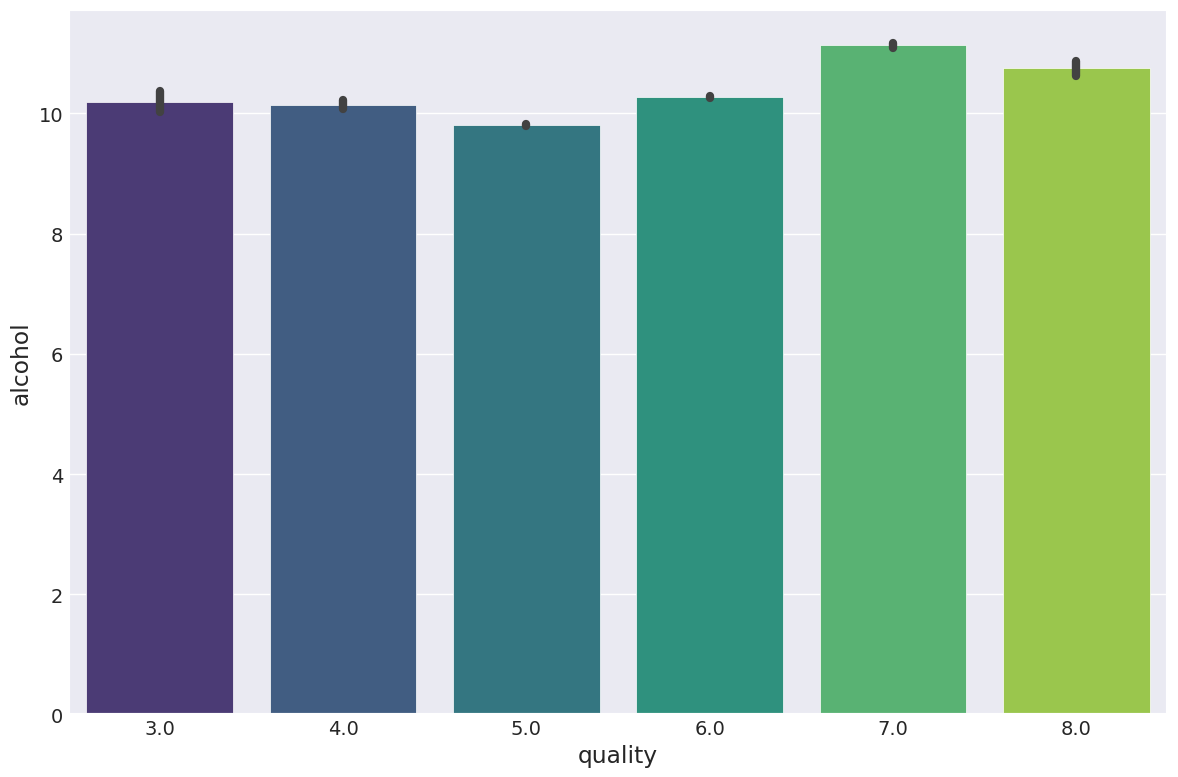

In [15]:
sns.barplot(df, x='quality', y='alcohol', palette='viridis')
plt.tight_layout()

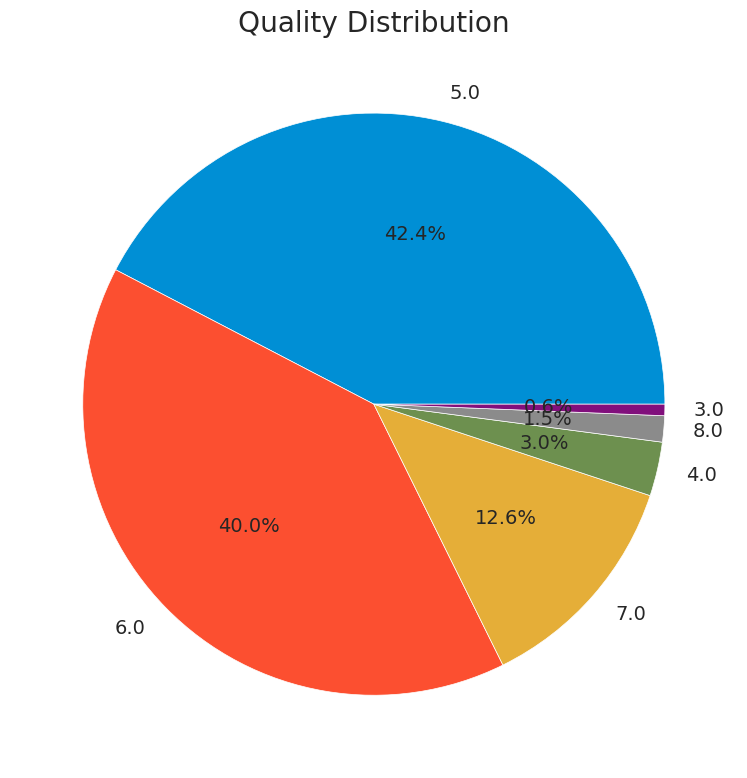

In [21]:
df.quality.value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Quality Distribution')
plt.ylabel('')
plt.tight_layout()

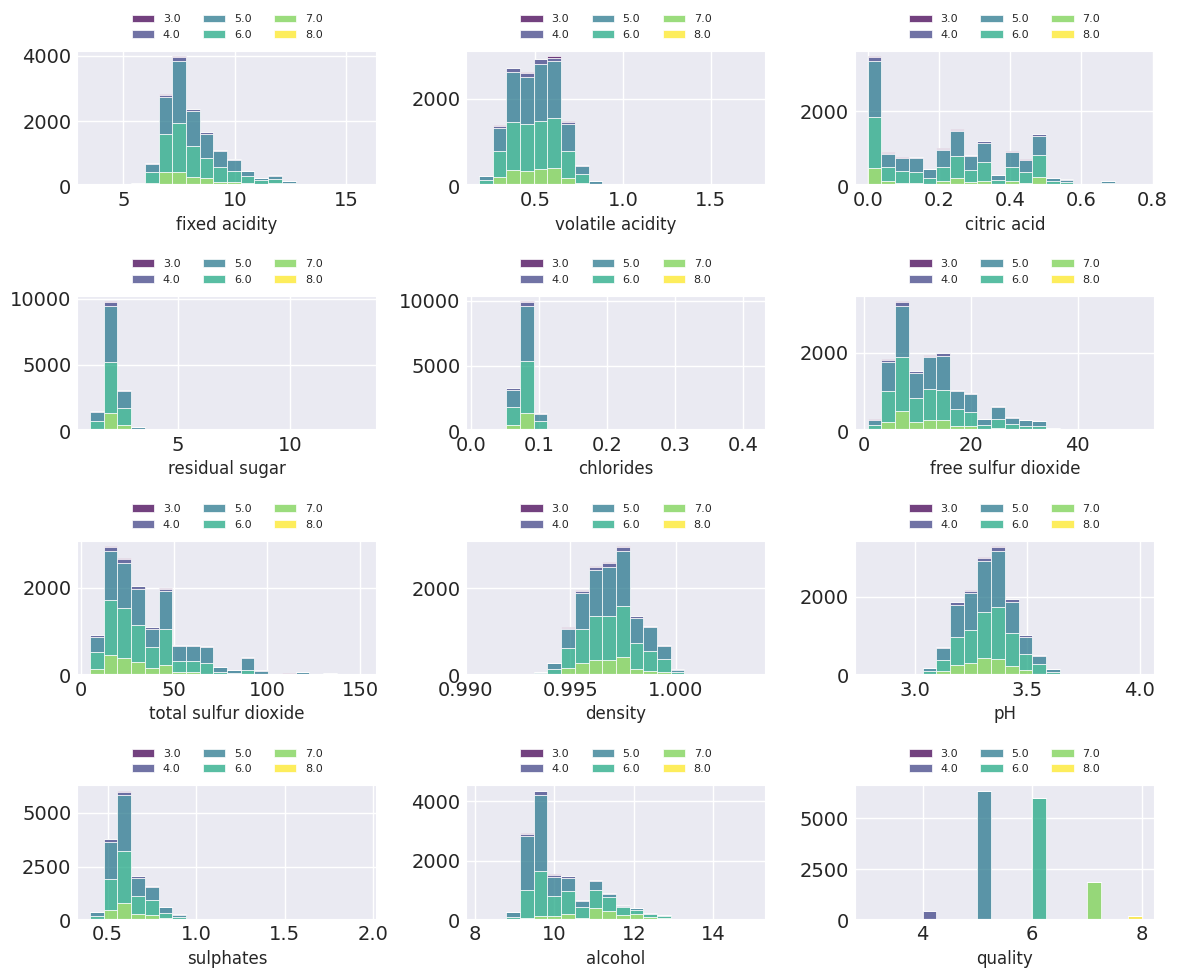

In [44]:
plt.figure(figsize=(12, 10))

for i, col in enumerate(df.columns):
    plt.subplot(4, 3, i + 1)
    ax = sns.histplot(df, x=col, bins=20, hue='quality', multiple='stack', palette='viridis')
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('')
    sns.move_legend(
        ax, "lower center",
        bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,
        fontsize=8
    )

plt.tight_layout()

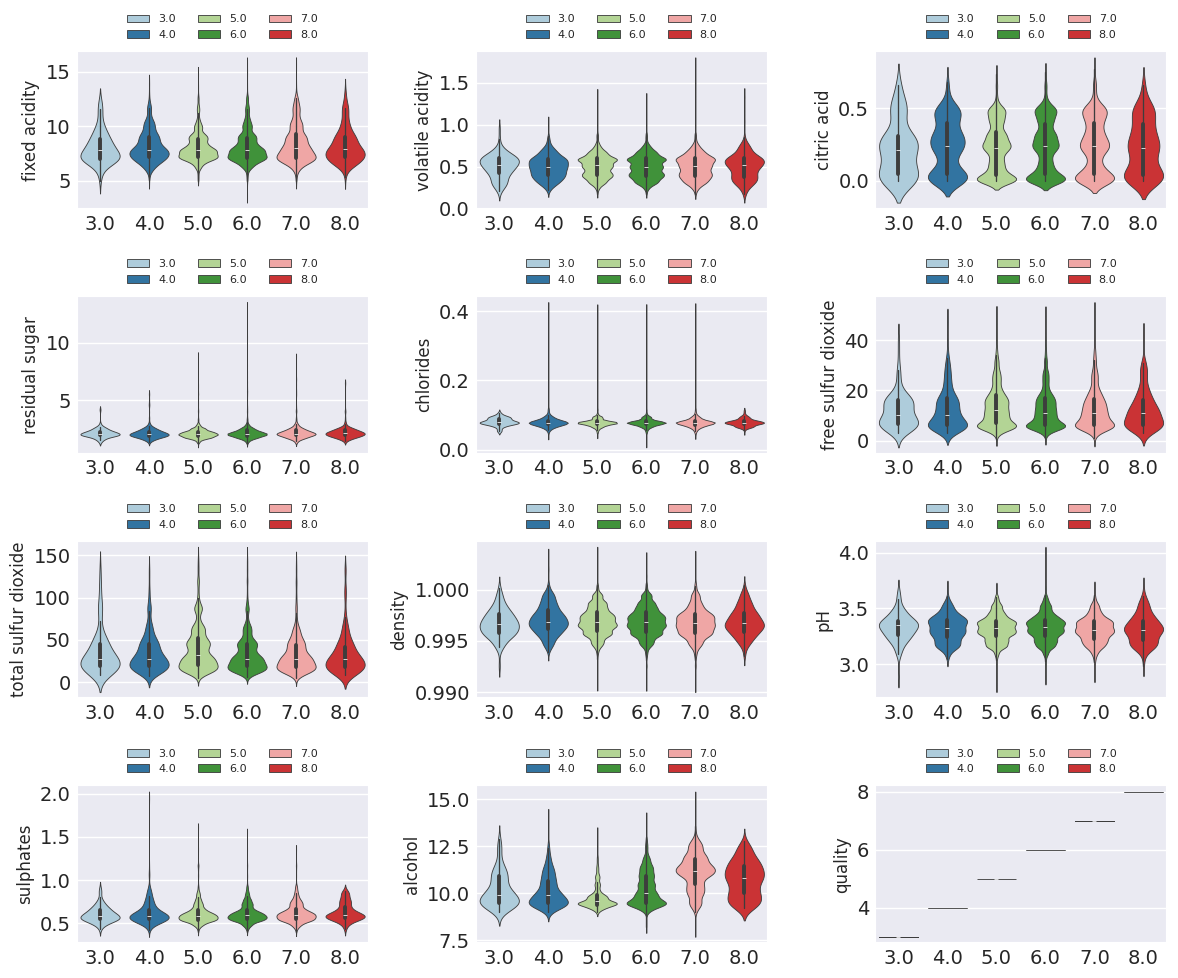

In [59]:
plt.figure(figsize=(12, 10))

for i, col in enumerate(df.columns):
    plt.subplot(4, 3, i + 1)
    ax = sns.violinplot(df, x='quality', y=col, hue='quality', palette='Paired')
    ax.set_xlabel('')
    ax.set_ylabel(col, fontsize=12)
    sns.move_legend(
        ax, "lower center",
        bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,
        fontsize=8
    )

plt.tight_layout()

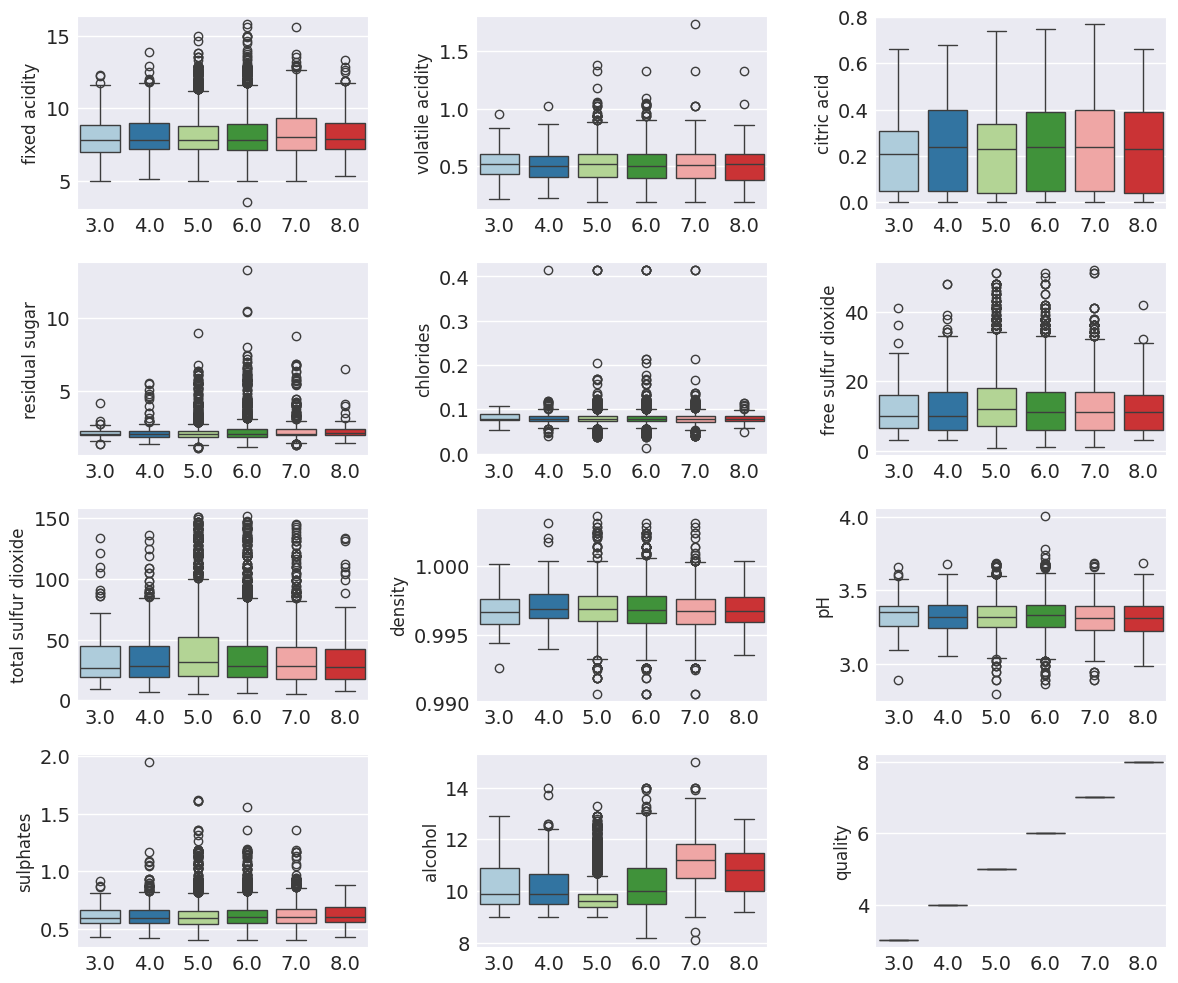

In [62]:
plt.figure(figsize=(12, 10))

for i, col in enumerate(df.columns):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(df, x='quality', y=col, palette='Paired')
    plt.xlabel('')
    plt.ylabel(col, fontsize=12)
plt.tight_layout()

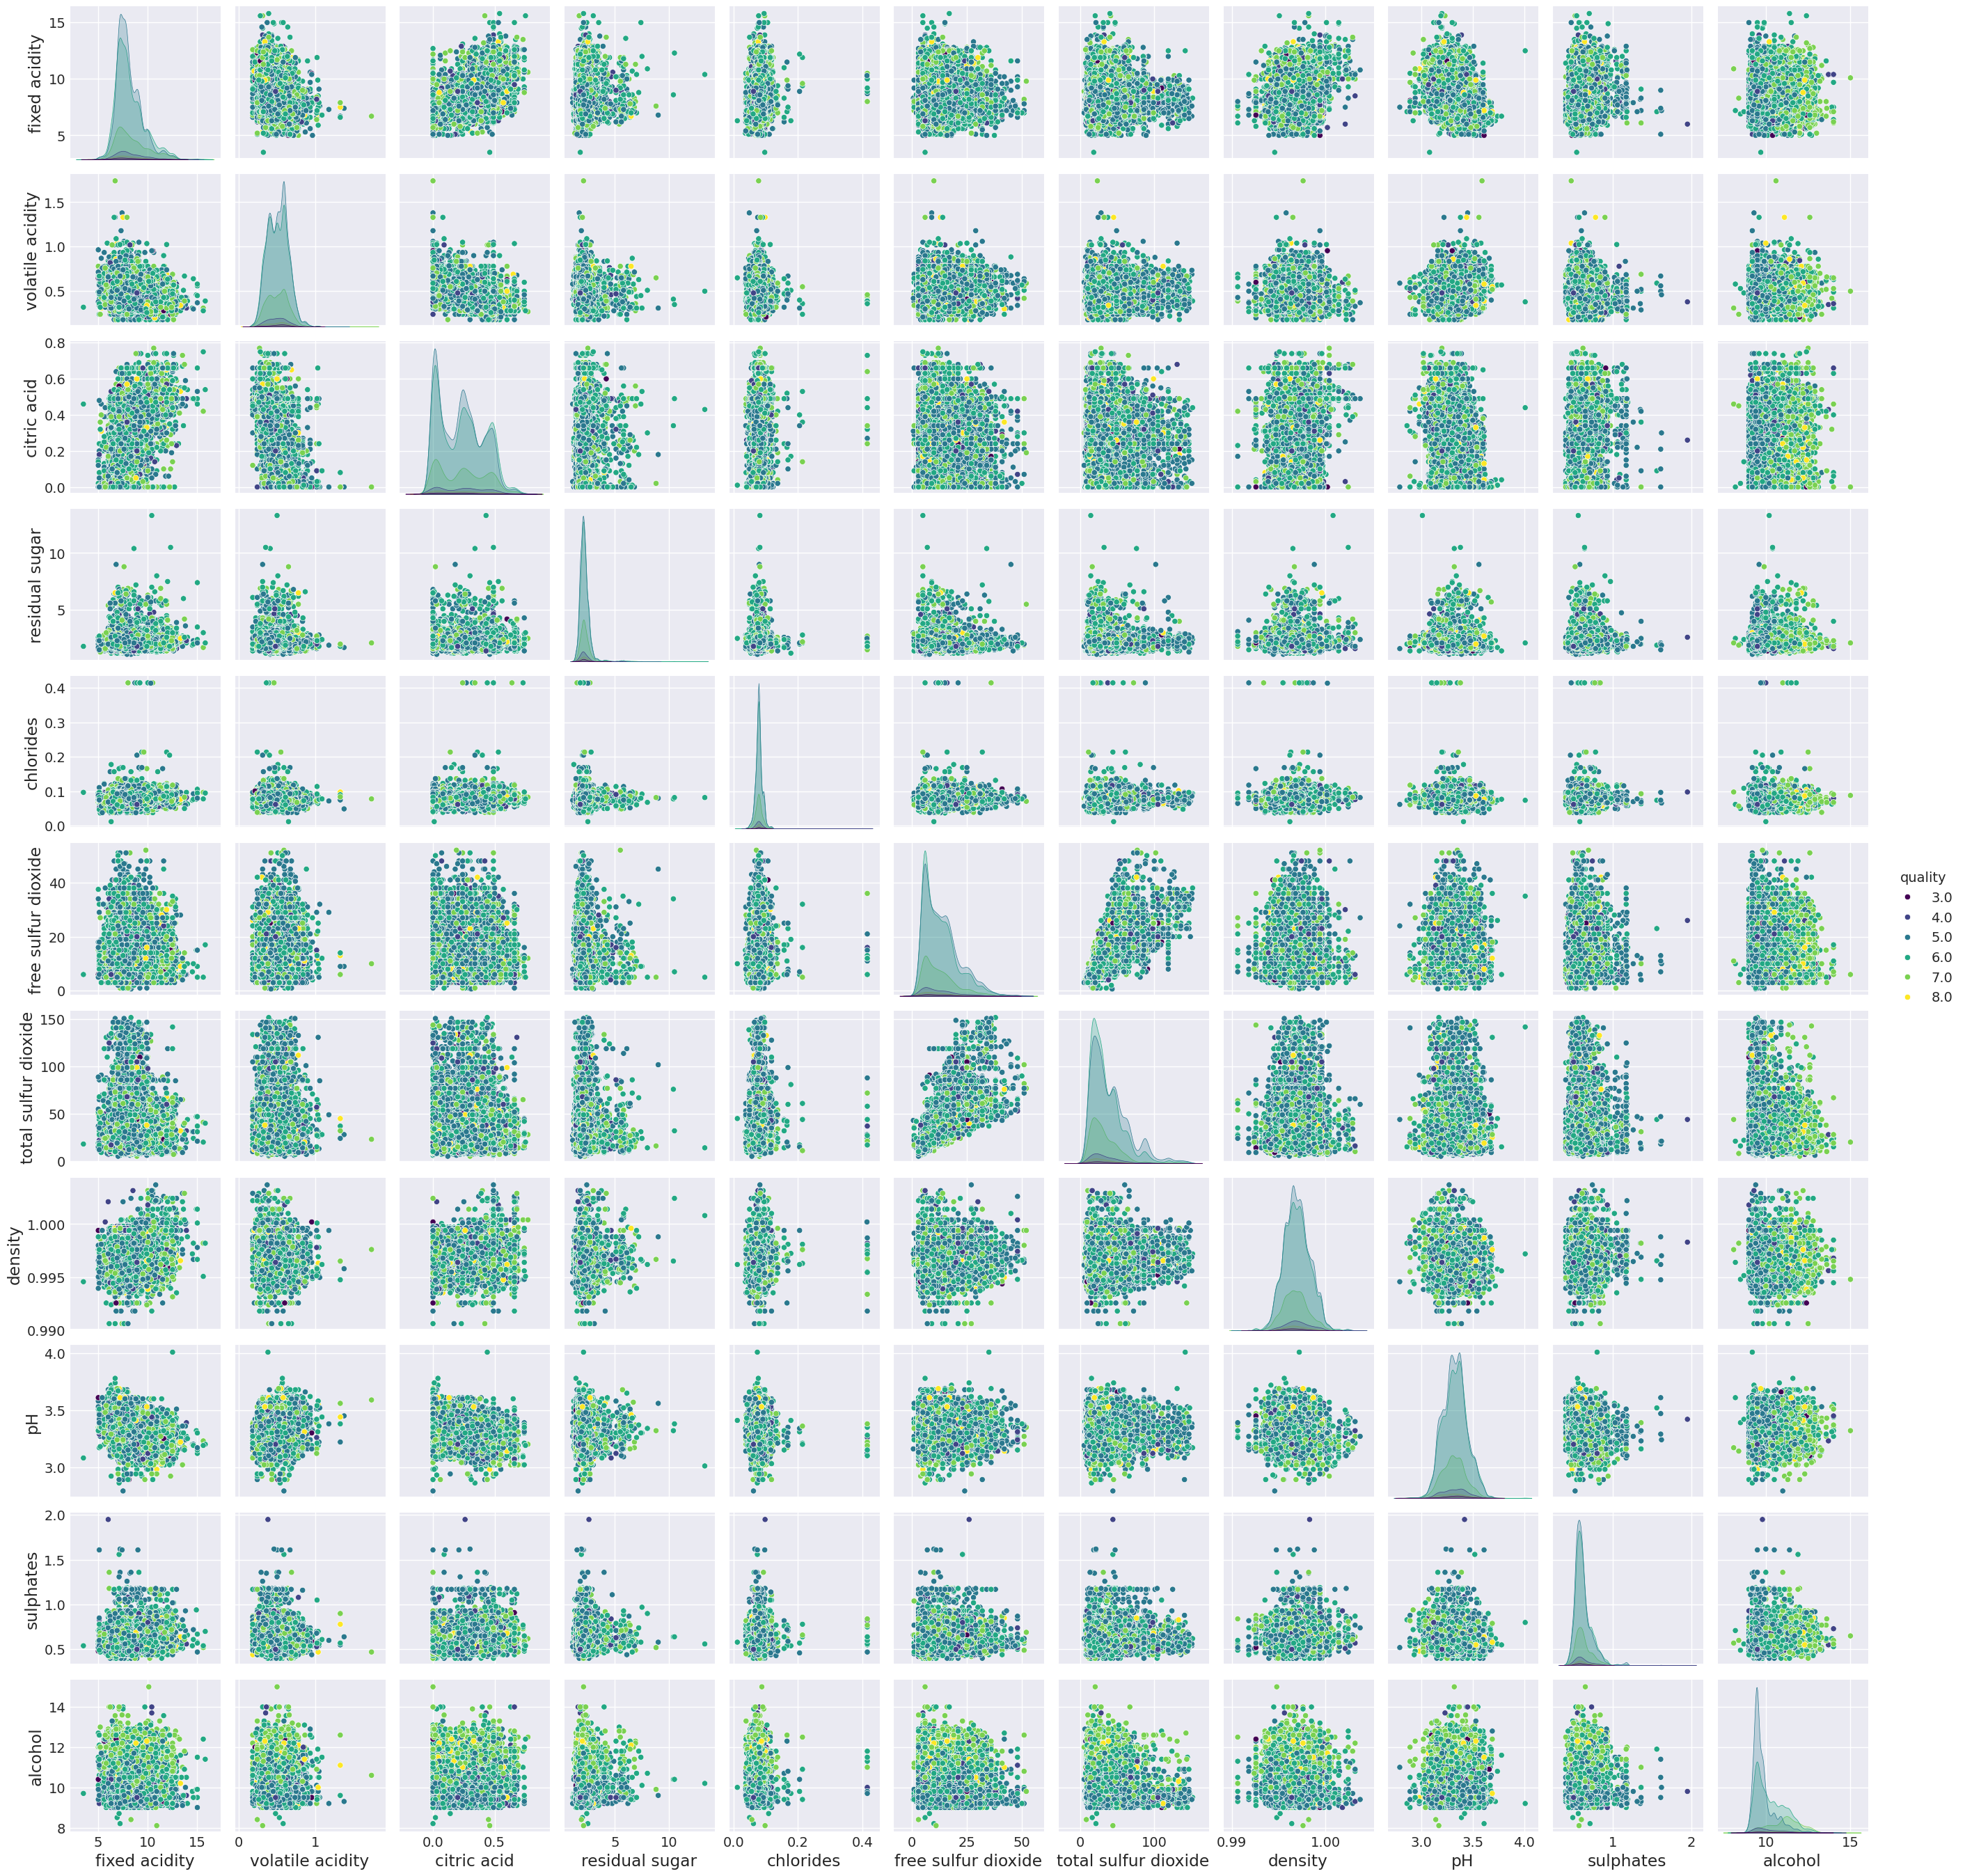

In [70]:
sns.pairplot(df, hue='quality', palette='viridis');

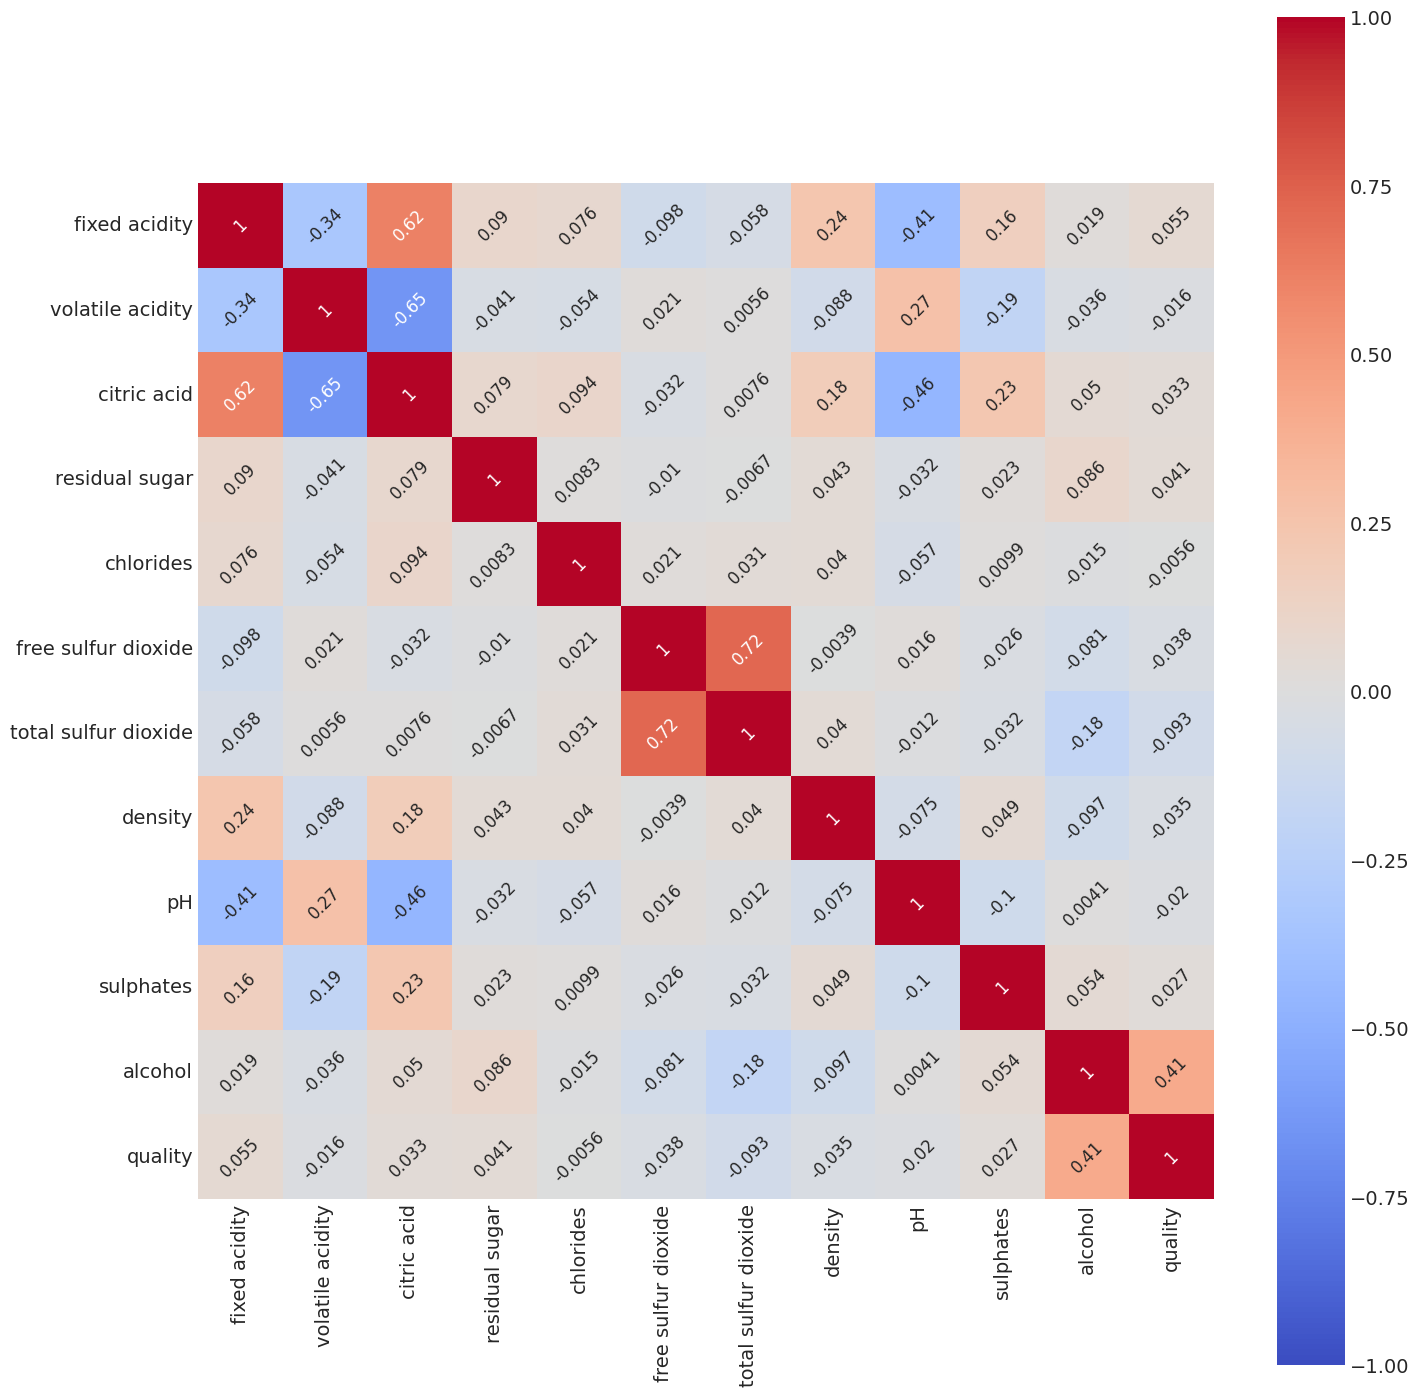

In [76]:
plt.figure(figsize=(15, 15))
sns.heatmap(
    df.corr(), 
    annot=True, 
    annot_kws={'rotation': 45, 'fontsize': 12},
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1,
    square=True
)
plt.tight_layout()

In [77]:
df.corr()['quality'].sort_values(ascending=False)

quality                 1.000000
alcohol                 0.409206
fixed acidity           0.055287
residual sugar          0.041071
citric acid             0.033279
sulphates               0.027000
chlorides              -0.005636
volatile acidity       -0.016020
pH                     -0.019805
density                -0.034728
free sulfur dioxide    -0.037644
total sulfur dioxide   -0.093470
Name: quality, dtype: float64

## 4. Data Preprocessing

In [149]:
x = df.drop(columns=['quality'])
y = df[['quality']]

In [150]:
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)

In [151]:
encoder = OrdinalEncoder()
y_encoded = encoder.fit_transform(y)

In [153]:
sm = SMOTE(random_state=42)
x_res, y_res = sm.fit_resample(x_scaled, y_encoded)

In [154]:
x_train, x_test, y_train, y_test = train_test_split(x_res, y_res, test_size=0.2, random_state=42)

## 5. Model Training

In [155]:
models = {
    'GaussianNB': GaussianNB(),
    'MultinomialNB': MultinomialNB(),
    'BernoulliNB': BernoulliNB(),
    'LogisticRegression': LogisticRegression(),
    'ExtraTreesClassifier': ExtraTreesClassifier(),
    'DecisionTreeClassifier': DecisionTreeClassifier(),
    'RandomForestClassifier': RandomForestClassifier(),
    'GradientBoostingClassifier': GradientBoostingClassifier(),
    'KNeighborsClassifier': KNeighborsClassifier(n_neighbors=5),
    'SVC': SVC(),
    'XGBClassifier': xgb.XGBClassifier(),
    'LightGBMClassifier': lgb.LGBMClassifier(verbose=-1)
}

def evaluate(x_train, y_train, x_test, y_test):
    results = []

    for i, (model_name, model) in enumerate(tqdm(models.items())):
        if 'random_state' in model.get_params():
            model.set_params(random_state=42)

        print(f'Training {model_name}...')
        y_pred = model.fit(x_train, y_train).predict(x_test)

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='macro')
        recall = recall_score(y_test, y_pred, average='macro')
        f1 = f1_score(y_test, y_pred, average='macro')

        plt.subplot(3, 5, i+1)
        sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(model_name, fontsize=12)
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()

        results.append({
            'Model': model_name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1 Score': f1
        })
        
    plt.suptitle('Confusion Matrices of All Models')
    plt.tight_layout()
    
    report = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
    report.reset_index(drop=True, inplace=True)
    return report

  0%|          | 0/12 [00:00<?, ?it/s]

Training GaussianNB...
Training MultinomialNB...
Training BernoulliNB...
Training LogisticRegression...
Training ExtraTreesClassifier...
Training DecisionTreeClassifier...
Training RandomForestClassifier...
Training GradientBoostingClassifier...
Training KNeighborsClassifier...
Training SVC...
Training XGBClassifier...
Training LightGBMClassifier...


,Model,Accuracy,Precision,Recall,F1 Score
0,ExtraTreesClassifier,0.817836,0.812876,0.820005,0.811806
1,RandomForestClassifier,0.806820,0.800162,0.808723,0.799291
2,XGBClassifier,0.774033,0.776040,0.775867,0.775220
3,LightGBMClassifier,0.763934,0.764786,0.765135,0.763265
4,KNeighborsClassifier,0.728000,0.690286,0.732703,0.691756
5,DecisionTreeClassifier,0.671738,0.665984,0.674195,0.669647
6,GradientBoostingClassifier,0.592000,0.583345,0.591773,0.583981
7,SVC,0.474361,0.455610,0.475272,0.441111
8,GaussianNB,0.287082,0.300676,0.287570,0.266146
9,LogisticRegression,0.286951,0.264611,0.284904,0.251189


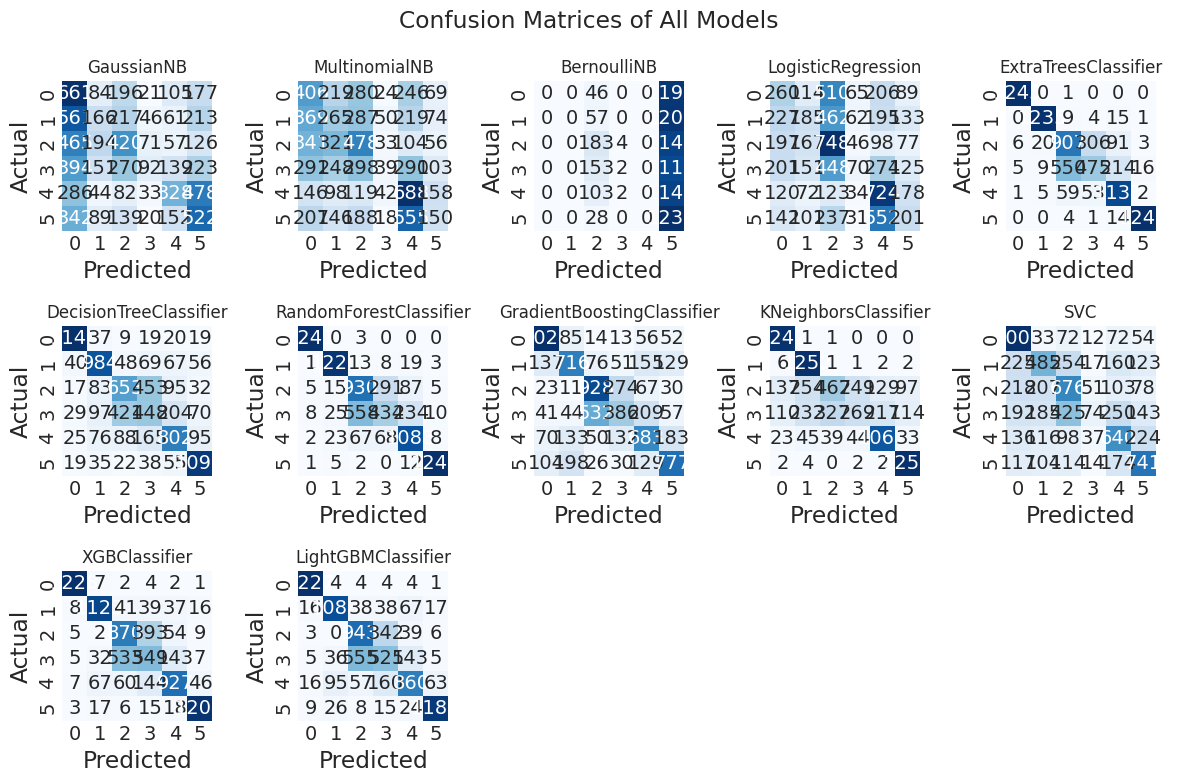

In [156]:
evaluate(x_train, y_train, x_test, y_test)

## 6. Build Pipeline with the best model, Save the model, Make Submission

In [159]:
encoder = OrdinalEncoder()
y_encoded = encoder.fit_transform(y)

In [160]:
sm = SMOTE(random_state=42)
x_res, y_res = sm.fit_resample(x, y_encoded)

In [161]:
preprocessor = ColumnTransformer([
    ('scaler', MinMaxScaler(), x.columns)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', ExtraTreesClassifier(random_state=42))
])

pipeline.fit(x_res, y_res)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [162]:
pipeline.score(x_res, y_res)

1.0

In [163]:
joblib.dump(pipeline, 'wine_quality_pipeline.pkl')
joblib.dump(encoder, 'wine_quality_encoder.pkl')

['wine_quality_encoder.pkl']

In [164]:
test_df = pd.read_csv('test.csv', index_col='id')
predictions = pipeline.predict(test_df)
submission = pd.DataFrame({
    'id': test_df.index,
    'quality': encoder.inverse_transform(predictions.reshape(-1, 1)).flatten()
})
submission.head()

,id,quality
0,15000,5.0
1,15001,6.0
2,15002,5.0
3,15003,7.0
4,15004,6.0


In [165]:
submission.to_csv('submission.csv', index=False)

## 7. Conclusion
We built a machine learning pipeline to predict the quality of wine. We used the `ExtraTreesClassifier` as the best model. We saved the pipeline for future use and used it to generate predictions for the test set.